In [40]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")

In [41]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [42]:
%cd /content/drive/MyDrive/melbourne_csv/

/content/drive/MyDrive/melbourne_csv


In [43]:
melb = pd.read_csv("Melbourne01.csv",low_memory=False,on_bad_lines="skip")

In [44]:
melb.head(30)

,2011,1,1.1,0,4,24.8,0.0,14.0,51,SE,11,13,1007.4,0.0.1
0,2011,1,1.0,0.0,4.0,24.8,0.0,14.0,51.0,SE,11.0,13.0,1007.4,0.0
1,2011,1,1.0,0.0,14.0,24.8,0.0,13.3,48.0,SE,11.0,11.0,1007.5,0.0
2,2011,1,1.0,0.0,14.0,24.8,0.0,13.3,48.0,SE,11.0,11.0,1007.5,0.0
3,2011,1,1.0,0.0,24.0,24.9,0.0,13.3,48.0,SE,11.0,13.0,1007.5,0.0
4,2011,1,1.0,0.0,24.0,24.9,0.0,13.3,48.0,SE,11.0,13.0,1007.5,0.0
5,2011,1,1.0,0.0,34.0,24.7,0.0,13.4,49.0,SE,11.0,11.0,1007.4,0.0
6,2011,1,1.0,0.0,34.0,24.7,0.0,13.4,49.0,SE,11.0,11.0,1007.4,0.0
7,2011,1,1.0,0.0,34.0,24.7,0.0,13.4,49.0,SE,11.0,11.0,1007.4,0.0
8,2011,1,1.0,0.0,44.0,24.1,0.0,13.3,51.0,ESE,9.0,9.0,1007.3,0.0
9,2011,1,1.0,0.0,54.0,24.3,0.0,13.3,50.0,NE,9.0,9.0,1007.3,0.0


In [45]:
melb.columns

Index(['2011', ' 1', ' 1.1', ' 0', ' 4', ' 24.8', ' 0.0', ' 14.0', ' 51',
       ' SE', ' 11', ' 13', ' 1007.4', ' 0.0.1'],
      dtype='object')

In [46]:
melb.columns = ['Year', 'Month', 'Day', 'Hour', 'Min', 'Air Temp (degrees C)',
       'Apparent Temp (degrees C)', 'Dew Pt Temp (degrees C)', 'Humidity (%)',
       'Wind Direction', 'Wind Speed (km/h)', 'Wind Gust  (km/h)',
       'MSLP (hPa)', 'Rainfall since 9 am (mm)'] # Fixes messy / unnamed columns


In [47]:
melb.drop_duplicates().reset_index(drop=True) # Removes repeated rows

,Year,Month,Day,Hour,Min,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm)
0,2011,1,1.0,0.0,4.0,24.8,0.0,14.0,51.0,SE,11.0,13.0,1007.4,0.0
1,2011,1,1.0,0.0,14.0,24.8,0.0,13.3,48.0,SE,11.0,11.0,1007.5,0.0
2,2011,1,1.0,0.0,24.0,24.9,0.0,13.3,48.0,SE,11.0,13.0,1007.5,0.0
3,2011,1,1.0,0.0,34.0,24.7,0.0,13.4,49.0,SE,11.0,11.0,1007.4,0.0
4,2011,1,1.0,0.0,44.0,24.1,0.0,13.3,51.0,ESE,9.0,9.0,1007.3,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
575950,2025,03,12.0,15.0,30.0,33.4,32.5,14.9,32.0,NW,20.0,35.0,1014.6,0.0
575951,2025,03,12.0,15.0,34.0,33.5,32.9,14.5,31.0,NNW,26.0,41.0,1014.6,0.0
575952,2025,03,12.0,16.0,0.0,34.4,34.2,14.8,30.0,WNW,26.0,41.0,1014.4,0.0
575953,2025,03,12.0,16.0,30.0,33.6,32.4,14.1,30.0,WNW,26.0,41.0,1014.1,0.0


In [48]:
melb_str = melb[melb["Month"].map(type) == str]

In [49]:
melb_str["Month"].unique()

array([' 1', ' 2', ' 3', ' 4', ' 5', ' 6', ' 7', ' 8', ' 9', ' 10', ' 11',
       ' 12', ' 1\t18\t11\t00\t18.8\t15.9\t9.6\t55\tS\t32\t43\t1014.8\t0',
       ' 1\t18\t11\t30\t20\t16.8\t10.1\t53\tS\t28\t43\t1015.1\t0',
       ' 1\t18\t12\t00\t19\t14.8\t11.1\t60\tS\t32\t43\t1015.4\t0',
       ' 1\t18\t12\t30\t19.2\t14.9\t9.4\t53\tSSE\t35\t48\t1015.6\t0',
       ' 1\t18\t13\t00\t19.4\t15.9\t8.7\t50\tS\t30\t44\t1015.9\t0',
       ' 1\t18\t13\t30\t19.5\t15.9\t8.5\t49\tS\t33\t50\t1016.2\t0',
       ' 1\t18\t14\t00\t19.3\t15.3\t8.3\t49\tSSE\t33\t46\t1016\t0',
       ' 1\t18\t14\t30\t19.3\t15.8\t8.9\t51\tS\t33\t50\t1015.9\t0',
       ' 1\t18\t15\t00\t19.4\t15.3\t8.7\t50\tS\t35\t48\t1015.6\t0',
       ' 1\t18\t15\t30\t19.2\t14.7\t7\t45\tS\t32\t46\t1015.6\t0',
       ' 1\t18\t16\t00\t19.3\t15.8\t7.1\t45\tS\t35\t50\t1015.8\t0',
       ' 1\t18\t16\t30\t19.5\t16.3\t10\t54\tS\t32\t48\t1015.8\t0',
       ' 1\t18\t17\t00\t19\t15\t8.9\t52\tSSE\t33\t41\t1015.8\t0',
       ' 1\t18\t17\t30\t18.6\t14.6\t8.3

In [50]:
tabbed_months = melb_str["Month"].unique()[12:28]

In [51]:
n_position = 580364
for month in tabbed_months:
    month = month.split("\t")
    empty_first = [""] + month
    row = pd.Series(empty_first)
    try:
        row = pd.to_numeric(row)
    except ValueError:
        pass
    row= row.to_list()
    melb.loc[n_position] = row
    melb.iloc[n_position,0] = 2017
    n_position +=1

/tmp/ipykernel_6926/137772692.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '18' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  melb.loc[n_position] = row
/tmp/ipykernel_6926/137772692.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '11' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  melb.loc[n_position] = row
/tmp/ipykernel_6926/137772692.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '00' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  melb.loc[n_position] = row
/tmp/ipykernel_6926/137772692.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a fut

In [52]:
fix_year = melb[melb['Month'].isna()].loc[::,"Year"]
indices = melb[melb['Month'].isna()].index.to_list()

In [53]:
y_position = 0
for year in fix_year:
    year = year.strip()
    year = year.split("\t")
    # row = pd.to_numeric(pd.Series(year), errors = 'ignore').to_list()

    row = pd.Series(year)
    try:
        row = pd.to_numeric(row)
    except ValueError:
        pass
    row=row.to_list()

    y_ind = indices[y_position]
    melb.loc[y_ind] = row
    y_position +=1               # Fixes rows where: data got merged into one column and tabs (\t) broke structure (frm.. melb_str...)

In [54]:
melb[melb['Month'].isna()]  #Fixes rows where year exists but Month is missing

,Year,Month,Day,Hour,Min,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm)


In [55]:
melb["Day"] = melb["Day"].astype(int) # Converts strings to numbers

In [56]:
replace_month = {' 1': 1,            # Removeing formatting inconsistencies
                 ' 2': 2,
                 ' 3': 3,
                 ' 4': 4,
                 ' 5': 5,
                 ' 6': 6,
                 ' 7': 7,
                 ' 8': 8,
                 ' 9': 9,
                 ' 10': 10,
                 ' 11': 11,
                 ' 12': 12,
                 ' 06': 6,
                 ' 03': 3,
                 ' 04': 4,
                 ' 05': 5,
                 ' 07': 7,
                 ' 08': 8,
                 ' 09': 9,
                 ' 01': 1,
                 ' 02': 2,
                 '09': 9,
                 '05': 5,
                 '02': 2,
                 '08': 8,
                 '1': 1,
                 '6': 6,
                 '8': 8,
                 '7': 7,
                 '5': 5,
                 '11':11
                }

In [57]:
melb["Month"] = melb["Month"].replace(replace_month)

/tmp/ipykernel_6926/984582946.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  melb["Month"] = melb["Month"].replace(replace_month)


In [58]:
replace_hour = {'06': 6,
                 '03': 3,
                 '04': 4,
                 '05': 5,
                 '07': 7,
                 '08': 8,
                 '09': 9,
                 '01': 1,
                 '02': 2,
                '00': 0
                }

In [59]:
melb["Hour"] = melb["Hour"].replace(replace_hour)
melb["Hour"] = melb["Hour"].astype(int)



In [60]:


melb['Min'] = melb['Min'].astype(int)

In [61]:
melb["Air Temp (degrees C)"] = melb["Air Temp (degrees C)"].astype(float)


In [62]:
melb["Apparent Temp (degrees C)"] = melb["Apparent Temp (degrees C)"].astype(float)


In [63]:
melb["Dew Pt Temp (degrees C)"] = melb["Dew Pt Temp (degrees C)"].astype(float)


In [64]:
melb['Humidity (%)'] = melb['Humidity (%)'].astype(int)


In [65]:
melb['Wind Gust  (km/h)'] = melb['Wind Gust  (km/h)'].astype(int)

In [66]:
melb['Wind Speed (km/h)'] = melb['Wind Speed (km/h)'].astype(int)

In [67]:
melb['MSLP (hPa)'] = melb['MSLP (hPa)'].astype(float)

In [68]:
melb['Rainfall since 9 am (mm)'] = melb['Rainfall since 9 am (mm)'].str.strip()
melb['Rainfall since 9 am (mm)'] = pd.to_numeric(melb['Rainfall since 9 am (mm)'], errors = 'coerce')

In [69]:
melb = melb.rename(columns={'Min': 'Minute'})

In [70]:
melb["Datetime"] = pd.to_datetime(melb[["Year","Month", "Hour", "Day", "Minute"]], errors = 'coerce')

In [71]:
melb

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime
0,2011,1,1,0,4,24.8,0.0,14.0,51,SE,11,13,1007.4,0.0,2011-01-01 00:04:00
1,2011,1,1,0,14,24.8,0.0,13.3,48,SE,11,11,1007.5,0.0,2011-01-01 00:14:00
2,2011,1,1,0,14,24.8,0.0,13.3,48,SE,11,11,1007.5,0.0,2011-01-01 00:14:00
3,2011,1,1,0,24,24.9,0.0,13.3,48,SE,11,13,1007.5,0.0,2011-01-01 00:24:00
4,2011,1,1,0,24,24.9,0.0,13.3,48,SE,11,13,1007.5,0.0,2011-01-01 00:24:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1113146,2025,3,12,15,30,33.4,32.5,14.9,32,NW,20,35,1014.6,0.0,2025-03-12 15:30:00
1113147,2025,3,12,15,34,33.5,32.9,14.5,31,NNW,26,41,1014.6,0.0,2025-03-12 15:34:00
1113148,2025,3,12,16,0,34.4,34.2,14.8,30,WNW,26,41,1014.4,0.0,2025-03-12 16:00:00
1113149,2025,3,12,16,30,33.6,32.4,14.1,30,WNW,26,41,1014.1,0.0,2025-03-12 16:30:00


In [72]:
with pd.option_context("display.max_rows",None):
    print(melb["Wind Direction"].value_counts())

Wind Direction
 N         276369
 S         136085
 W          87480
 WSW        81667
 SW         80151
 SSW        76062
 SSE        71341
 NNE        65602
 WNW        55938
 NNW        55817
 NW         40438
 SE         26632
 CALM       19598
 NE         15075
 ESE         8582
 E           7827
 ENE         7791
N             205
SW             75
S              62
SSW            60
W              43
WSW            39
WNW            30
NNE            27
NNW            20
CALM           17
NW             17
SSE            15
SE              8
 -              6
ENE             5
NE              5
 1016.6         4
 1015.9         3
E               2
ESE             2
 1015.6         2
 1017.0         2
 1017.4         2
 1014.6         2
 1019.5         2
 1021.0         2
 1020.4         2
 1016.1         2
 1019.0         1
 1026.1         1
 1025.3         1
 1014.2         1
 1015.5         1
 1026.0         1
 1024.2         1
 1008.2         1
 1003.3         1
 1029.6      

In [73]:
melb["Wind Direction"].unique()

array([' SE', ' ESE', ' NE', ' NNE', ' ENE', ' W', ' N', ' SW', ' SSE',
       ' S', ' SSW', ' WSW', ' NW', ' WNW', ' NNW', ' E', ' CALM',
       ' 1016.6', ' 1016.9', ' 1017.0', ' 1017.4', ' 1026.0', ' 1026.1',
       ' 1025.3', ' 1024.2', ' 1029.6', ' 1003.3', ' 1008.2', ' 1019.0',
       'ENE', 'NE', 'N', 'NNE', 'NNW', 'NW', 'SSW', 'SW', 'WSW', 'W',
       'WNW', ' 1015.5', 'S', 'SE', 'SSE', 'ESE', 'CALM', 'E', ' 1014.2',
       ' 1015.9', ' 1016.2', ' 1016.1', ' 1014.1', ' 1014.0', ' 1013.6',
       ' 1012.7', ' 1013.1', ' 1014.4', ' 1014.6', ' 1015.6', ' 1015.8',
       ' 1016.7', ' 1017.2', ' 1016.0', ' 1017.8', ' 1019.5', ' 1019.8',
       ' 1019.9', ' 1020.4', ' 1021.0', ' 1021.2', ' 1021.7', ' 1021.9',
       ' 1022.3', ' 1022.7', ' 1004.5', ' 1022.0', ' 1010.3', ' 1012.0',
       ' 1010.8', ' -'], dtype=object)

In [74]:
replace_direction = {' SE': 'SE',
                     ' ESE': 'ESE',
                     ' NE': 'NE',
                     ' NNE': 'NNE',
                     ' ENE': 'ENE',
                     ' W': 'W',
                     ' N': 'W',
                     ' SW': 'SW',
                     ' SSE': 'SSE',
                     ' S': 'S',
                     ' SSW': 'SSW',
                     ' WSW': 'WSW',
                     ' NW': 'NW',
                     ' WNW': 'WNW',
                     ' NNW': 'NNW',
                     ' E': 'E',
                     ' CALM': 'STILL',
                     'CALM': 'STILL',
                    ' -': "STILL"}

In [75]:
melb["Wind Direction"] = melb["Wind Direction"].replace(replace_direction)

In [76]:
melb["Wind Direction"].unique()

array(['SE', 'ESE', 'NE', 'NNE', 'ENE', 'W', 'SW', 'SSE', 'S', 'SSW',
       'WSW', 'NW', 'WNW', 'NNW', 'E', 'STILL', ' 1016.6', ' 1016.9',
       ' 1017.0', ' 1017.4', ' 1026.0', ' 1026.1', ' 1025.3', ' 1024.2',
       ' 1029.6', ' 1003.3', ' 1008.2', ' 1019.0', 'N', ' 1015.5',
       ' 1014.2', ' 1015.9', ' 1016.2', ' 1016.1', ' 1014.1', ' 1014.0',
       ' 1013.6', ' 1012.7', ' 1013.1', ' 1014.4', ' 1014.6', ' 1015.6',
       ' 1015.8', ' 1016.7', ' 1017.2', ' 1016.0', ' 1017.8', ' 1019.5',
       ' 1019.8', ' 1019.9', ' 1020.4', ' 1021.0', ' 1021.2', ' 1021.7',
       ' 1021.9', ' 1022.3', ' 1022.7', ' 1004.5', ' 1022.0', ' 1010.3',
       ' 1012.0', ' 1010.8'], dtype=object)

In [77]:
melb["Wind Direction"].unique()

array(['SE', 'ESE', 'NE', 'NNE', 'ENE', 'W', 'SW', 'SSE', 'S', 'SSW',
       'WSW', 'NW', 'WNW', 'NNW', 'E', 'STILL', ' 1016.6', ' 1016.9',
       ' 1017.0', ' 1017.4', ' 1026.0', ' 1026.1', ' 1025.3', ' 1024.2',
       ' 1029.6', ' 1003.3', ' 1008.2', ' 1019.0', 'N', ' 1015.5',
       ' 1014.2', ' 1015.9', ' 1016.2', ' 1016.1', ' 1014.1', ' 1014.0',
       ' 1013.6', ' 1012.7', ' 1013.1', ' 1014.4', ' 1014.6', ' 1015.6',
       ' 1015.8', ' 1016.7', ' 1017.2', ' 1016.0', ' 1017.8', ' 1019.5',
       ' 1019.8', ' 1019.9', ' 1020.4', ' 1021.0', ' 1021.2', ' 1021.7',
       ' 1021.9', ' 1022.3', ' 1022.7', ' 1004.5', ' 1022.0', ' 1010.3',
       ' 1012.0', ' 1010.8'], dtype=object)

In [78]:
# pd.set_option('display.max_rows', 20)
directions = melb["Wind Direction"].unique()

In [79]:
melb[melb["Wind Direction"] == ' 1016.6']

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime
155560,2012,9,24,13,44,14.8,6.8,0.5,37,1016.6,0,0,0.0,0.0,2012-09-24 13:44:00
155561,2012,9,24,13,44,14.8,6.8,0.5,37,1016.6,0,0,0.0,0.0,2012-09-24 13:44:00
491736,2016,2,7,8,50,22.3,22.3,14.2,60,1016.6,0,0,0.0,0.0,2016-02-07 08:50:00
491738,2016,2,7,9,0,22.9,23.4,13.9,57,1016.6,0,0,0.0,0.0,2016-02-07 09:00:00


In [80]:
melb[melb["Wind Direction"] == ' 1017.0']

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime
155563,2012,9,24,14,14,13.4,6.8,4.2,53,1017.0,0,0,0.0,0.0,2012-09-24 14:14:00
155564,2012,9,24,14,34,14.3,7.0,2.3,44,1017.0,0,0,0.0,0.0,2012-09-24 14:34:00


In [81]:
di_i = 0
for di in directions:

    fixed = di.strip()
    try:
        fixed = float(fixed)
    except (ValueError,TypeError):
        pass
    if isinstance(fixed,float):
        indx_list = melb.index[melb["Wind Direction"] == di].to_list()
        for i in indx_list:
            melb.loc[i,"MSLP (hPa)"] = fixed

In [82]:
melb[melb["Wind Direction"] == ' 1016.6']

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime
155560,2012,9,24,13,44,14.8,6.8,0.5,37,1016.6,0,0,1016.6,0.0,2012-09-24 13:44:00
155561,2012,9,24,13,44,14.8,6.8,0.5,37,1016.6,0,0,1016.6,0.0,2012-09-24 13:44:00
491736,2016,2,7,8,50,22.3,22.3,14.2,60,1016.6,0,0,1016.6,0.0,2016-02-07 08:50:00
491738,2016,2,7,9,0,22.9,23.4,13.9,57,1016.6,0,0,1016.6,0.0,2016-02-07 09:00:00


In [83]:
melb[melb["Wind Direction"] == ' 1017.0']

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime
155563,2012,9,24,14,14,13.4,6.8,4.2,53,1017.0,0,0,1017.0,0.0,2012-09-24 14:14:00
155564,2012,9,24,14,34,14.3,7.0,2.3,44,1017.0,0,0,1017.0,0.0,2012-09-24 14:34:00


In [84]:
for i in range(melb.shape[0]):
    if melb.loc[i, "Wind Speed (km/h)"] == 0 and melb.loc[i, "Wind Direction"] != "STILL":
        melb.loc[i, "Wind Direction"] = "STILL"

    if melb.loc[i, "Wind Direction"] == "STILL" and melb.loc[i, "Wind Speed (km/h)"] > 0.0:
        melb.loc[i, "Wind Direction"] = None

    if melb.loc[i, "Wind Speed (km/h)"] <0:
        melb.loc[i, "Wind Direction"] = None
        melb.loc[i, "Wind Speed (km/h)"] = None

    if melb.loc[i, "Wind Gust  (km/h)"] <0:
        melb.loc[i, "Wind Gust  (km/h)"] = None
        # melb.loc[i, "Wind Speed (km/h)"] = None

In [85]:
with pd.option_context('display.max_rows', None):
    print(melb["Wind Speed (km/h)"].value_counts())

Wind Speed (km/h)
13.0     93443
15.0     92110
11.0     90386
17.0     89537
9.0      83570
19.0     77005
20.0     61226
7.0      60520
22.0     54449
24.0     52009
26.0     50239
28.0     47251
30.0     39606
32.0     32826
0.0      31952
33.0     26615
35.0     21726
6.0      19908
37.0     17014
39.0     13219
41.0     10467
43.0      8221
44.0      6604
4.0       5885
46.0      5341
48.0      4428
2.0       3783
50.0      3630
52.0      2808
54.0      2171
56.0      1529
57.0      1120
59.0       752
61.0       540
63.0       381
65.0       281
67.0       181
69.0       137
70.0        76
72.0        58
74.0        41
76.0        34
80.0        20
78.0        15
83.0        10
82.0         6
85.0         6
87.0         3
89.0         2
100.0        2
1.0          1
3.0          1
Name: count, dtype: int64


In [86]:
# When there is a positive wind speed and wind direction is "STILL", I will change the wind direction to an "NaN"

# When there is a wind speed of 0, and a classified wind direction, I will change the wind direction to "STILL".

# done!

In [87]:
# melb[melb["Wind Direction"] == ' 1012.0'].index

melb.loc[657500, "Wind Direction"] = None
melb.loc[657481, "Wind Direction"] = None
melb.loc[657500, "Wind Speed (km/h)"] = None

melb.loc[657481, "Wind Speed (km/h)"] = None

In [88]:
with pd.option_context('display.float_format', '{:.2f}'.format):
    print(melb.describe())

           Month        Day       Hour     Minute  Air Temp (degrees C)  \
count 1113151.00 1113151.00 1113151.00 1113151.00            1113151.00   
mean        6.45      15.76      11.44      26.12                 15.78   
min         1.00       1.00       0.00       0.00                  0.50   
25%         3.00       8.00       5.00      10.00                 11.80   
50%         6.00      16.00      11.00      30.00                 15.10   
75%         9.00      23.00      17.00      40.00                 18.90   
max        12.00      31.00      23.00      59.00                 43.50   
std         3.44       8.81       6.89      17.24                  5.62   

       Apparent Temp (degrees C)  Dew Pt Temp (degrees C)  Humidity (%)  \
count                 1113151.00               1113151.00    1113151.00   
mean                       12.05                     9.01         66.95   
min                     -9999.00                    -9.60          0.00   
25%                     

In [89]:
melb.loc[melb["MSLP (hPa)"] <0, "MSLP (hPa)"] = None # Removes impossible values

In [90]:
melb.describe()

,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime
count,1.113151e+06,1.113151e+06,1.113151e+06,1.113151e+06,1.113151e+06,1.113151e+06,1.113151e+06,1.113151e+06,1.113143e+06,1.113140e+06,1.113117e+06,1.112596e+06,1113151
mean,6.449869e+00,1.576466e+01,1.143807e+01,2.611543e+01,1.577788e+01,1.205041e+01,9.006135e+00,6.695214e+01,1.932511e+01,2.260400e+01,1.017328e+03,7.823287e-01,2016-12-30 11:54:40.273780480
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,5.000000e-01,-9.999000e+03,-9.600000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.881000e+02,0.000000e+00,2011-01-01 00:04:00
25%,3.000000e+00,8.000000e+00,5.000000e+00,1.000000e+01,1.180000e+01,7.600000e+00,6.000000e+00,5.500000e+01,1.100000e+01,1.300000e+01,1.012300e+03,0.000000e+00,2014-02-06 13:40:00
50%,6.000000e+00,1.600000e+01,1.100000e+01,3.000000e+01,1.510000e+01,1.170000e+01,8.500000e+00,6.800000e+01,1.700000e+01,2.000000e+01,1.017400e+03,0.000000e+00,2016-10-17 13:50:00
75%,9.000000e+00,2.300000e+01,1.700000e+01,4.000000e+01,1.890000e+01,1.650000e+01,1.160000e+01,8.000000e+01,2.600000e+01,3.000000e+01,1.022600e+03,2.000000e-01,2019-10-13 06:35:00
max,1.200000e+01,3.100000e+01,2.300000e+01,5.900000e+01,4.350000e+01,4.330000e+01,3.690000e+01,1.000000e+02,1.000000e+02,1.090000e+02,1.041900e+03,5.460000e+01,2025-03-12 16:30:00
std,3.442491e+00,8.809506e+00,6.886329e+00,1.724355e+01,5.615222e+00,1.517278e+01,4.062210e+00,1.766679e+01,1.059140e+01,1.272109e+01,7.636249e+00,2.955180e+00,NaN


In [91]:
melb.head()

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime
0,2011,1,1,0,4,24.8,0.0,14.0,51,SE,11.0,13.0,1007.4,0.0,2011-01-01 00:04:00
1,2011,1,1,0,14,24.8,0.0,13.3,48,SE,11.0,11.0,1007.5,0.0,2011-01-01 00:14:00
2,2011,1,1,0,14,24.8,0.0,13.3,48,SE,11.0,11.0,1007.5,0.0,2011-01-01 00:14:00
3,2011,1,1,0,24,24.9,0.0,13.3,48,SE,11.0,13.0,1007.5,0.0,2011-01-01 00:24:00
4,2011,1,1,0,24,24.9,0.0,13.3,48,SE,11.0,13.0,1007.5,0.0,2011-01-01 00:24:00


In [92]:
melb.dtypes

,0
Year,object
Month,int64
Day,int64
Hour,int64
Minute,int64
Air Temp (degrees C),float64
Apparent Temp (degrees C),float64
Dew Pt Temp (degrees C),float64
Humidity (%),int64
Wind Direction,object


In [93]:
melb.head()

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime
0,2011,1,1,0,4,24.8,0.0,14.0,51,SE,11.0,13.0,1007.4,0.0,2011-01-01 00:04:00
1,2011,1,1,0,14,24.8,0.0,13.3,48,SE,11.0,11.0,1007.5,0.0,2011-01-01 00:14:00
2,2011,1,1,0,14,24.8,0.0,13.3,48,SE,11.0,11.0,1007.5,0.0,2011-01-01 00:14:00
3,2011,1,1,0,24,24.9,0.0,13.3,48,SE,11.0,13.0,1007.5,0.0,2011-01-01 00:24:00
4,2011,1,1,0,24,24.9,0.0,13.3,48,SE,11.0,13.0,1007.5,0.0,2011-01-01 00:24:00


In [94]:
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn import metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

# XGBoost
from xgboost import XGBClassifier
from xgboost import plot_importance

pd.set_option("display.max_columns", 50)

In [96]:
# Make sure Datetime is the index and sorted chronologically
melb = melb.dropna(subset=["Datetime"]).sort_values("Datetime").set_index("Datetime")
print(f"Date range: {melb.index.min().date()} to {melb.index.max().date()}")

Date range: 2011-01-01 to 2025-03-12


In [97]:
# Aggregate to daily
agg_rules = {
    "Air Temp (degrees C)": ["min", "max", "mean"],
    "Apparent Temp (degrees C)": ["mean"],
    "Dew Pt Temp (degrees C)": ["mean"],
    "Humidity (%)": ["mean", "max"],
    "MSLP (hPa)": ["mean", "min", "max"],
    "Wind Speed (km/h)": ["max", "mean"],
    "Wind Gust  (km/h)": ["max"],
    "Rainfall since 9 am (mm)": ["max"],
}

daily = melb.resample("D").agg(agg_rules)

# Flatten the multi-index column names: ('Air Temp (degrees C)', 'min') -> 'Air Temp_min'
daily.columns = [f"{col[0].split(' (')[0]}_{col[1]}" for col in daily.columns]

# Wind direction needs special handling: take the daily mode
wind_dir_daily = melb["Wind Direction"].resample("D").agg(
    lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else np.nan
)
daily["Wind_Direction"] = wind_dir_daily

# Rename the rainfall column for sanity
daily = daily.rename(columns={"Rainfall since 9 am_max": "rainfall_mm"})

print(f"Daily dataset: {daily.shape[0]:,} days, {daily.shape[1]} columns")
daily.head()

Daily dataset: 5,185 days, 15 columns


,Air Temp_min,Air Temp_max,Air Temp_mean,Apparent Temp_mean,Dew Pt Temp_mean,Humidity_mean,Humidity_max,MSLP_mean,MSLP_min,MSLP_max,Wind Speed_max,Wind Speed_mean,Wind Gust _max,rainfall_mm,Wind_Direction
Datetime,,,,,,,,,,,,,,,
2011-01-01,16.8,24.9,19.650787,0.0,11.987008,61.574803,80.0,1011.803543,1007.2,1015.2,37.0,14.350394,43.0,0.0,S
2011-01-02,15.3,21.4,18.175258,0.0,8.078351,52.097938,71.0,1016.319072,1013.9,1017.6,33.0,21.891753,39.0,0.0,S
2011-01-03,14.1,20.3,16.590734,0.0,5.467954,47.814672,57.0,1016.943629,1015.6,1018.5,35.0,24.389961,41.0,0.0,S
2011-01-04,12.9,21.5,16.800775,0.0,8.856589,59.879845,85.0,1012.389922,1009.7,1016.3,30.0,15.709302,37.0,0.0,SSE
2011-01-05,14.6,21.3,18.117188,0.0,11.730078,66.585938,79.0,1010.092578,1008.2,1012.4,32.0,19.898438,37.0,0.0,S


In [98]:
# Target: did it rain TOMORROW (>0.2 mm)?
daily["rain_tomorrow"] = (daily["rainfall_mm"].shift(-1) > 0.2).astype(int)

# Class balance check
print("Class distribution:")
print(daily["rain_tomorrow"].value_counts())
print(f"\nRain rate: {daily['rain_tomorrow'].mean():.1%}")

Class distribution:
rain_tomorrow
0    2952
1    2233
Name: count, dtype: int64

Rain rate: 43.1%


In [99]:
# Variables we want to lag
lag_vars = ["rainfall_mm", "Humidity_mean", "MSLP_mean", "Air Temp_mean"]

for var in lag_vars:
    for lag in [1, 2, 3]:
        daily[f"{var}_lag{lag}"] = daily[var].shift(lag)

# Add month for seasonality (December rain != June rain in Melbourne)
daily["month"] = daily.index.month

print(f"After feature engineering: {daily.shape[1]} columns")
daily.head()

After feature engineering: 29 columns


,Air Temp_min,Air Temp_max,Air Temp_mean,Apparent Temp_mean,Dew Pt Temp_mean,Humidity_mean,Humidity_max,MSLP_mean,MSLP_min,MSLP_max,Wind Speed_max,Wind Speed_mean,Wind Gust _max,rainfall_mm,Wind_Direction,rain_tomorrow,rainfall_mm_lag1,rainfall_mm_lag2,rainfall_mm_lag3,Humidity_mean_lag1,Humidity_mean_lag2,Humidity_mean_lag3,MSLP_mean_lag1,MSLP_mean_lag2,MSLP_mean_lag3,Air Temp_mean_lag1,Air Temp_mean_lag2,Air Temp_mean_lag3,month
Datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2011-01-01,16.8,24.9,19.650787,0.0,11.987008,61.574803,80.0,1011.803543,1007.2,1015.2,37.0,14.350394,43.0,0.0,S,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2011-01-02,15.3,21.4,18.175258,0.0,8.078351,52.097938,71.0,1016.319072,1013.9,1017.6,33.0,21.891753,39.0,0.0,S,0,0.0,NaN,NaN,61.574803,NaN,NaN,1011.803543,NaN,NaN,19.650787,NaN,NaN,1
2011-01-03,14.1,20.3,16.590734,0.0,5.467954,47.814672,57.0,1016.943629,1015.6,1018.5,35.0,24.389961,41.0,0.0,S,0,0.0,0.0,NaN,52.097938,61.574803,NaN,1016.319072,1011.803543,NaN,18.175258,19.650787,NaN,1
2011-01-04,12.9,21.5,16.800775,0.0,8.856589,59.879845,85.0,1012.389922,1009.7,1016.3,30.0,15.709302,37.0,0.0,SSE,0,0.0,0.0,0.0,47.814672,52.097938,61.574803,1016.943629,1016.319072,1011.803543,16.590734,18.175258,19.650787,1
2011-01-05,14.6,21.3,18.117188,0.0,11.730078,66.585938,79.0,1010.092578,1008.2,1012.4,32.0,19.898438,37.0,0.0,S,0,0.0,0.0,0.0,59.879845,47.814672,52.097938,1012.389922,1016.943629,1016.319072,16.800775,16.590734,18.175258,1


In [100]:
# One-hot encode wind direction
daily = pd.get_dummies(daily, columns=["Wind_Direction"], prefix="wind", dummy_na=False)

# Drop rows with NaN (mostly from lag features at the start, and the last row from the shift)
daily_model = daily.dropna()

print(f"Final modelling dataset: {daily_model.shape[0]:,} rows, {daily_model.shape[1]} columns")
daily_model.head()

Final modelling dataset: 5,177 rows, 45 columns


,Air Temp_min,Air Temp_max,Air Temp_mean,Apparent Temp_mean,Dew Pt Temp_mean,Humidity_mean,Humidity_max,MSLP_mean,MSLP_min,MSLP_max,Wind Speed_max,Wind Speed_mean,Wind Gust _max,rainfall_mm,rain_tomorrow,rainfall_mm_lag1,rainfall_mm_lag2,rainfall_mm_lag3,Humidity_mean_lag1,Humidity_mean_lag2,Humidity_mean_lag3,MSLP_mean_lag1,MSLP_mean_lag2,MSLP_mean_lag3,Air Temp_mean_lag1,Air Temp_mean_lag2,Air Temp_mean_lag3,month,wind_E,wind_ENE,wind_ESE,wind_N,wind_NE,wind_NNE,wind_NNW,wind_NW,wind_S,wind_SE,wind_SSE,wind_SSW,wind_STILL,wind_SW,wind_W,wind_WNW,wind_WSW
Datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2011-01-04,12.9,21.5,16.800775,0.0,8.856589,59.879845,85.0,1012.389922,1009.7,1016.3,30.0,15.709302,37.0,0.0,0,0.0,0.0,0.0,47.814672,52.097938,61.574803,1016.943629,1016.319072,1011.803543,16.590734,18.175258,19.650787,1,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
2011-01-05,14.6,21.3,18.117188,0.0,11.730078,66.585938,79.0,1010.092578,1008.2,1012.4,32.0,19.898438,37.0,0.0,0,0.0,0.0,0.0,59.879845,47.814672,52.097938,1012.389922,1016.943629,1016.319072,16.800775,16.590734,18.175258,1,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
2011-01-06,15.9,30.6,22.265737,0.0,13.376096,59.832669,87.0,1008.880478,1005.7,1012.5,24.0,12.043825,32.0,0.0,0,0.0,0.0,0.0,66.585938,59.879845,47.814672,1010.092578,1012.389922,1016.943629,18.117188,16.800775,16.590734,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
2011-01-07,21.5,33.3,27.417578,0.0,12.814844,41.140625,65.0,1007.711719,1006.4,1009.4,54.0,33.480469,63.0,0.0,1,0.0,0.0,0.0,59.832669,66.585938,59.879845,1008.880478,1010.092578,1012.389922,22.265737,18.117188,16.800775,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
2011-01-08,19.4,34.3,26.731034,0.0,14.755172,49.531034,84.0,1008.495172,1006.2,1015.3,43.0,28.841379,52.0,0.6,1,0.0,0.0,0.0,41.140625,59.832669,66.585938,1007.711719,1008.880478,1010.092578,27.417578,22.265737,18.117188,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False


In [119]:
# Separate features (X) and target (y)
y = daily_model["rain_tomorrow"]
X = daily_model.drop(columns=["rain_tomorrow"])

# Chronological 75/25 split
split_idx = int(len(daily_model) * 0.75)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training set: {X_train.shape[0]:,} days  ({X_train.index.min().date()} to {X_train.index.max().date()})")
print(f"Test set:     {X_test.shape[0]:,} days  ({X_test.index.min().date()} to {X_test.index.max().date()})")
print(f"\nTrain rain rate: {y_train.mean():.1%}")
print(f"Test rain rate:  {y_test.mean():.1%}")

Training set: 3,882 days  (2011-01-04 to 2021-08-25)
Test set:     1,295 days  (2021-08-26 to 2025-03-12)

Train rain rate: 42.8%
Test rain rate:  43.9%


In [120]:
xgb = XGBClassifier(
    objective="binary:logistic",
    random_state=0,
    eval_metric="logloss",
)

# Step 2: hyperparameter grid (kept small — same shape as exemplar's grid)
cv_params = {
    "max_depth": [4, 6, 8],
    "min_child_weight": [1, 5],
    "learning_rate": [0.1, 0.2],
    "n_estimators": [100, 200],
}

# Step 3: scoring dict — track all four metrics, refit on F1
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
}

# Step 4: GridSearchCV with time-series-aware CV
tscv = TimeSeriesSplit(n_splits=5)

xgb_cv = GridSearchCV(
    estimator=xgb,
    param_grid=cv_params,
    scoring=scoring,
    cv=tscv,
    refit="f1",
    n_jobs=-1,
    verbose=1,
)

print(f"Grid size: {3*2*2*2} combinations x 5 folds = {3*2*2*2*5} fits")



Grid size: 24 combinations x 5 folds = 120 fits


In [121]:
%%time
# Fit the grid search — this is the slow step
xgb_cv.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
CPU times: user 2.75 s, sys: 82.6 ms, total: 2.83 s
Wall time: 1min 3s


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamm...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.1, 0.2], 'max_depth': [4, 6, 8],
                         'min_child_weight': [1, 5],
                         'n_estimators': [100, 200]},
             refit='f1',
             scoring={'accuracy': 'accuracy', 'f1': 'f1',
                      'precision': 'precision', 'recall': 'recall'},
             verbose=1)

In [122]:
print("Best parameters:")
for k, v in xgb_cv.best_params_.items():
    print(f"  {k}: {v}")

print(f"\nBest CV F1 score: {xgb_cv.best_score_:.4f}")

Best parameters:
  learning_rate: 0.1
  max_depth: 8
  min_child_weight: 5
  n_estimators: 200

Best CV F1 score: 0.7047


In [124]:
# Predict on test set
y_pred = xgb_cv.best_estimator_.predict(X_test)
y_pred_proba = xgb_cv.best_estimator_.predict_proba(X_test)[:, 1]

# Quick look at the first 10 predictions
pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred,
    "rain_probability": y_pred_proba.round(3),
}, index=y_test.index).head(30)

,actual,predicted,rain_probability
Datetime,,,
2021-08-26,0,0,0.344
2021-08-27,0,0,0.089
2021-08-28,1,1,0.691
2021-08-29,1,1,0.978
2021-08-30,0,1,0.634
2021-08-31,0,0,0.267
2021-09-01,0,0,0.080
2021-09-02,1,0,0.323
2021-09-03,1,1,0.980


In [131]:
ac_score = accuracy_score(y_test, y_pred)
pc_score = precision_score(y_test, y_pred)
rc_score = recall_score(y_test, y_pred)
f1_score_val = f1_score(y_test, y_pred)

print(f"Accuracy:{ac_score:.4f}")
print(f"Precision:{pc_score:.4f}")
print(f"Recall:{rc_score:.4f}")
print(f"F1 score:{f1_score_val:.4f}")

Accuracy:0.7707
Precision:0.7845
Recall:0.6591
F1 score:0.7163


In [126]:
# Full classification report (gives per-class precision/recall/F1)
print(classification_report(y_test, y_pred, target_names=["No Rain", "Rain"]))

              precision    recall  f1-score   support

     No Rain       0.76      0.86      0.81       726
        Rain       0.78      0.66      0.72       569

    accuracy                           0.77      1295
   macro avg       0.77      0.76      0.76      1295
weighted avg       0.77      0.77      0.77      1295



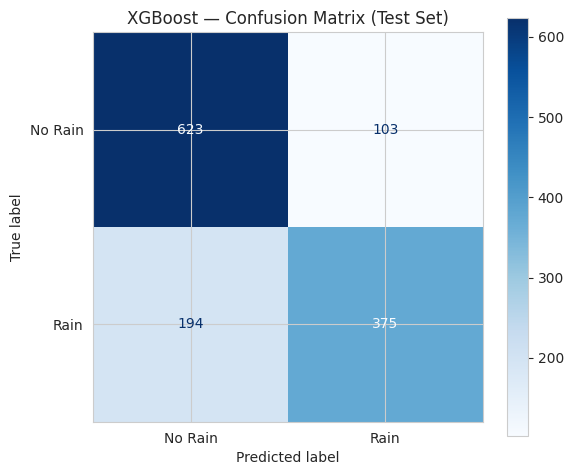


True Negatives (correctly said 'no rain'): 623
False Positives (false alarms):            103
False Negatives (missed rain):             194
True Positives (correctly caught rain):    375


In [127]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Rain", "Rain"])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("XGBoost — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives (correctly said 'no rain'):{tn}")
print(f"False Positives (false alarms):{fp}")
print(f"False Negatives (missed rain):{fn}")
print(f"True Positives (correctly caught rain):{tp}")

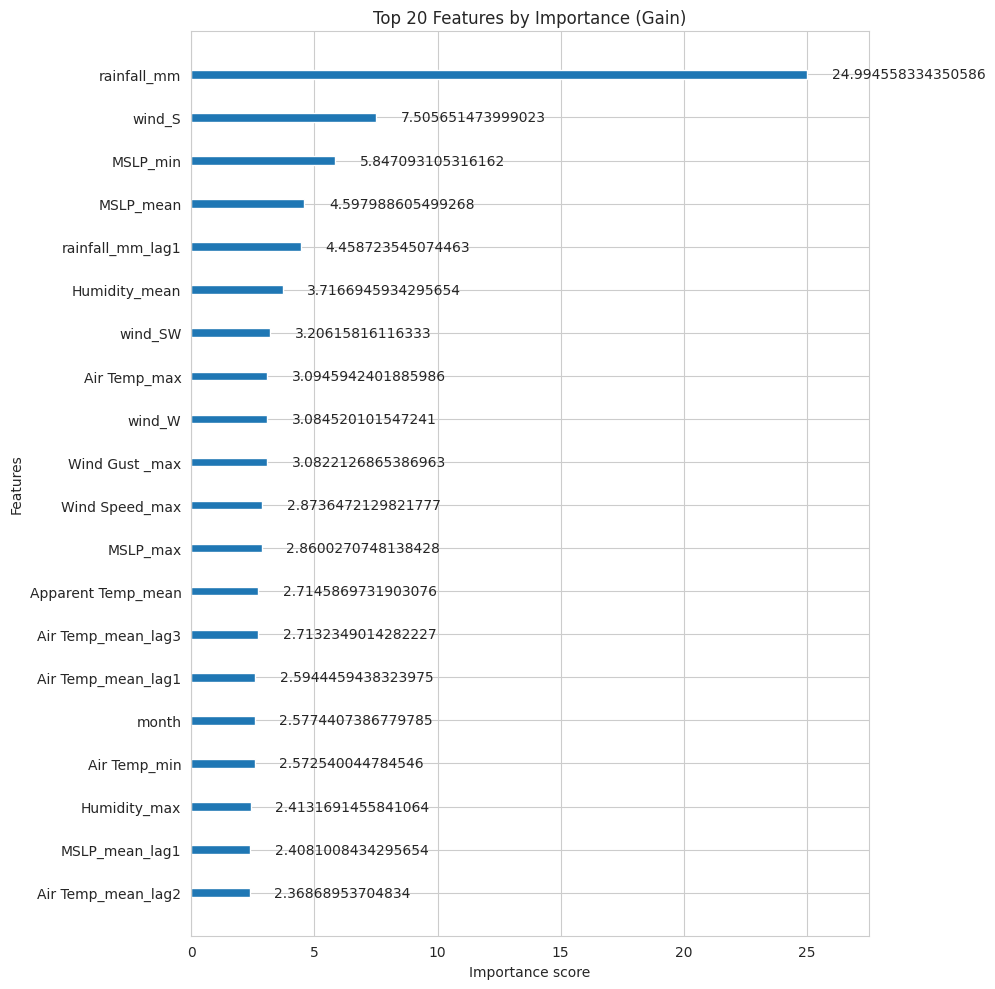

In [128]:
fig, ax = plt.subplots(figsize=(10, 10))
plot_importance(xgb_cv.best_estimator_, ax=ax, max_num_features=20, importance_type="gain")
plt.title("Top 20 Features by Importance (Gain)")
plt.tight_layout()
plt.show()

In [130]:
# Build comparison table
# Replace the decision tree and random forest scores with your real ones if you have them
results = pd.DataFrame([
    {"Model": "Baseline (always 'no rain')",
     "Accuracy": (y_test == 0).mean(),
     "Precision": 0.0,
     "Recall": 0.0,
     "F1": 0.0},
    # {"Model": "Tuned Decision Tree", "F1": ..., "Recall": ..., "Precision": ..., "Accuracy": ...},
    # {"Model": "Tuned Random Forest", "F1": ..., "Recall": ..., "Precision": ..., "Accuracy": ...},
    {"Model": "Tuned XGBoost",
     "Accuracy": ac_score,
     "Precision": pc_score,
     "Recall": rc_score,
     "F1": f1_score_val},
])

results.round(4)

,Model,Accuracy,Precision,Recall,F1
0,Baseline (always 'no rain'),0.5606,0.0000,0.0000,0.0000
1,Tuned XGBoost,0.7707,0.7845,0.6591,0.7163
